# See, Detect, Understand: Computer Vision introduction

## WORKED SOLUTION AND PRESENTER GUIDE

**NUS Statistics and Data Science Society**

> **Your role:** You are prototyping photo tags for a campus photo collection. Your prototype should suggest an ImageNet category for a photograph and display the model's scores. You will also investigate when those suggestions are unreliable.

### Learning goals

By the end of this introductory example, you should be able to:

- Read an image's shape and explain its RGB pixel values.
- Prepare an image for an existing CNN and run a prediction.
- Explain the difference between inference, training and transfer learning.
- Interpret model scores and identify limitations of a fixed category list.

### Workshop route

| Section | Activity | Suggested use |
| --- | --- | --- |
| 0. Setup | Load the tools and a sample image | Provided code |
| 1. Image representation | Inspect numbers and RGB channels | Exercise 1 |
| 2. Image classification | Resize, batch, preprocess and predict | Exercises 2-5 |
| 3. Investigating mistakes | Compare original and blurred images | Optional discussion |
| 4. Your turn | Investigate one new image and explain its results | Optional short challenge |
| 5. Features and CNN intuition | Compare a fixed edge filter with learned activations | Optional presenter extension |

Sections 0-2 support a **10-15 minute presenter demonstration**. Allow about **20-25 minutes** if participants complete the five exercises. These are suggested timings for Wei Tao's segment, not the full two-hour workshop schedule.

### How to use this template

1. Open [Google Colab](https://colab.research.google.com/) and choose **File > Upload notebook**.
2. Connect to a Python runtime. A default CPU runtime is enough for this small inference example.
3. Run code cells in order using the play button or **Shift+Enter**.
4. Exercises 1-5 contain complete code. Use this version to learn the pipeline and demonstrate it during the workshop.
5. Solution explanations follow each exercise. A presenter appendix at the end includes slide content, a suggested sequence and preparation notes.

The first run downloads a sample photo, model weights and the ImageNet label lookup. Internet access is required. You do not need a GPU, a training dataset or a mounted Google Drive for this example.

# Section 0: Setup and sample image

The libraries have different jobs: **NumPy** stores numbers, **Pillow** opens images, **Matplotlib** displays them, and **TensorFlow/Keras** runs the model. `import` makes these tools available to Python.

Colab normally includes these packages. Run this cell first. If an import fails, try a fresh standard runtime before changing packages.

In [ ]:
import io
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image, ImageOps, ImageFilter, UnidentifiedImageError
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.21.0
NumPy: 2.1.3


## A common example for everyone

Keep `image_source = "sample"` for your first run. Everyone will use the same Labrador photograph from a TensorFlow tutorial. Later, change it to `"upload"` to select one JPEG or PNG from your computer.

The supplied code handles downloading and file opening so you can focus on the vision concepts. `convert("RGB")` ensures the image has three colour channels. `exif_transpose` respects orientation information from a camera.

**Image credit:** *YellowLabradorLooking new.jpg*, original photo by Elf, derivative/retouch by Djmirko and FT2, via [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:YellowLabradorLooking_new.jpg), [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/). The image transformations shown in this notebook include resizing, channel views, blur and an edge view. The transformed sample image views retain this image credit and licence.

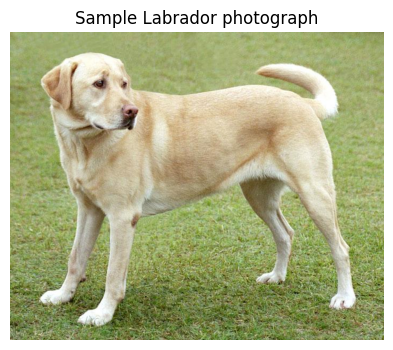

In [ ]:
image_source = "sample"  # Change to "upload" when you want to try your own photo.

if image_source == "sample":
    image_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"
    image_path = tf.keras.utils.get_file("YellowLabradorLooking_new.jpg", origin=image_url)
    with Image.open(image_path) as image_file:
        img = ImageOps.exif_transpose(image_file).convert("RGB")
    image_name = "Sample Labrador photograph"
elif image_source == "upload":
    from google.colab import files
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("Rerun this cell and upload exactly one JPEG or PNG image.")
    image_name = next(iter(uploaded))
    try:
        with Image.open(io.BytesIO(uploaded[image_name])) as image_file:
            img = ImageOps.exif_transpose(image_file).convert("RGB")
    except UnidentifiedImageError as exc:
        raise ValueError("Try a JPEG or PNG. Export HEIC phone photos to JPEG first.") from exc
else:
    raise ValueError('image_source must be "sample" or "upload".')

plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.title(image_name)
plt.axis("off")
plt.show()

# Section 1: How does a computer see?

> **Guiding question 1:** What numbers represent this photograph?

An RGB image has shape **(height, width, 3)**. Each pixel contains red, green and blue channel values. In this 8-bit representation, each value ranges from 0 to 255.

**Exercise 1:** Convert `img` to a NumPy array named `pixels`. Then read the shape and the top-left pixel.

<details><summary>Hint</summary>
NumPy's `asarray` function converts an image into an array. Python starts indexing from zero, so `pixels[0, 0]` selects the first row and first column.
</details>

In [ ]:
pixels = np.asarray(img)

print("Shape (height, width, channels):", pixels.shape)
print("First pixel [R, G, B]:", pixels[0, 0]) #first pixel in the first row
print("Red-channel values in a 5x5 patch:") #only the red channel values in the 25 pixels at the top left
print(pixels[:5, :5, 0])

Shape (height, width, channels): (577, 700, 3)
First pixel [R, G, B]: [162 167 101]
Red-channel values in a 5x5 patch:
[[162 157 151 151 154]
 [159 156 152 152 154]
 [153 154 154 155 155]
 [148 151 154 156 154]
 [144 148 153 152 153]]


**Answer discussion:** `np.asarray(img)` turns the Pillow image into an array. The sample file has shape `(577, 700, 3)`; uploaded photos can have different heights and widths. The final `3` counts RGB channels, not objects in the image. Pixel values depend on the image you use.

## RGB channels

The supplied cell shows the three channels as intensity plots. All panels use the same 0-255 range. These are three measurements at each location in the same photograph.

**Pause and discuss:** What colour does `[255, 0, 0]` represent? What about `[0, 0, 0]` and `[255, 255, 255]`?

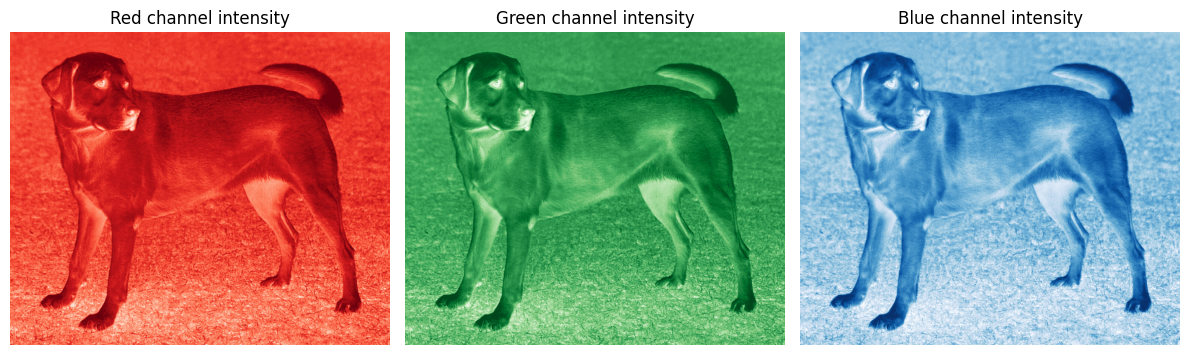

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for channel, (name, colour_map) in enumerate(
    [("Red", "Reds"), ("Green", "Greens"), ("Blue", "Blues")]
):
    axes[channel].imshow(pixels[:, :, channel], cmap=colour_map, vmin=0, vmax=255)
    axes[channel].set_title(name + " channel intensity")
    axes[channel].axis("off")
plt.tight_layout()
plt.show()

## Vocabulary checkpoint

| Term | Meaning in this example |
| --- | --- |
| Pixel | Values at one location in an image |
| Channel | One measurement per location, such as red intensity |
| Shape | The dimensions of an array |
| Batch | A collection of examples that a model processes together |
| Class or label | One of the model's possible output categories |
| Feature | Information that helps a model make a prediction |

An image's dimensions describe the input. They do not tell us its semantic category. We need a model to connect visual patterns to categories.

# Section 2: Image classification with a pretrained CNN

> **Guiding question 2:** How can we turn these numbers into a label for the photo?

MobileNetV2 is a **convolutional neural network**, or CNN. Its convolutional layers use learned filters to respond to local patterns. Later layers combine earlier representations into information useful for classification.

`weights="imagenet"` loads parameters learned from ImageNet. We keep the existing classifier, which scores 1,000 ImageNet categories. The supplied cell loads the model once.

| Process | What happens |
| --- | --- |
| Training | Labelled examples and a loss guide changes to learned parameters |
| Inference | An existing model uses its learned parameters to make predictions |
| Transfer learning | We reuse a pretrained representation and train a classifier for a new task, with optional further fine-tuning |

This notebook demonstrates **inference**. Simply uploading a photo does not train or adapt the model.

In [ ]:
model = MobileNetV2(weights="imagenet", include_top=True)
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

Model input shape: (None, 224, 224, 3)
Model output shape: (None, 1000)


## Exercise 2: Resize the image

Our default classifier expects a **224 x 224 RGB image**.

Replace `None` with the target size tuple. Then compare the original and resized shapes. Simple resizing may stretch a photo; we use it here to keep the first pipeline easy to follow.

<details><summary>Hint</summary>
Pillow's `resize` takes a `(width, height)` tuple. Both values should be 224 in this example.
</details>

In [ ]:
target_size = (224, 224)
model_img = img.resize(target_size, Image.Resampling.BILINEAR)
image_array = np.asarray(model_img, dtype=np.float32)
print("Original shape:", pixels.shape)
print("Resized shape:", image_array.shape)
assert image_array.shape == (224, 224, 3), "Check the target size and RGB channels."

Original shape: (577, 700, 3)
Resized shape: (224, 224, 3)


**Answer discussion:** `(224, 224)` sets width and height. The resulting array has shape `(224, 224, 3)` and dtype `float32`. We change representation and resolution while preserving three channels.

## Exercise 3: Add a batch dimension

The model expects **(batch size, height, width, channels)**. For one photo, this is `(1, 224, 224, 3)`.

Replace `None` with code that adds a new dimension at axis 0.

<details><summary>Hint</summary>
Use NumPy's `expand_dims` function on `image_array`, with `axis=0`. This groups the image into a batch containing one example.
</details>

In [ ]:
batch = np.expand_dims(image_array, axis=0)
print("Batch shape:", batch.shape)
assert batch.shape == (1, 224, 224, 3), "The first dimension should count one image."

Batch shape: (1, 224, 224, 3)


**Answer discussion:** `np.expand_dims(image_array, axis=0)` changes the shape to `(1, 224, 224, 3)`. The leading `1` counts images. It does not change the image's channels or add new visual information.

## Exercise 4: Apply model-specific preprocessing

MobileNetV2 expects values scaled from `[0, 255]` into `[-1, 1]`. Call its `preprocess_input` function on a copy of `batch` to create `x`.

Do not divide by 255 first. MobileNetV2's preprocessing already performs the required scaling. Another model may use another convention.

<details><summary>Hint</summary>
`preprocess_input` is already imported from MobileNetV2. Pass it `batch.copy()` so the original 0-255 values remain available for comparison.
</details>

In [ ]:
x = preprocess_input(batch.copy())
print("Original first pixel:", batch[0, 0, 0])
print("Preprocessed first pixel:", x[0, 0, 0])
print("Input shape:", x.shape)
print("Input range:", float(x.min()), "to", float(x.max()))
assert np.allclose(x, batch / 127.5 - 1.0), "Check model-specific scaling."

Original first pixel: [155. 160.  95.]
Preprocessed first pixel: [ 0.21568632  0.254902   -0.25490195]
Input shape: (1, 224, 224, 3)
Input range: -0.9607843160629272 to 1.0


**Answer discussion:** `preprocess_input(batch.copy())` applies the expected mapping, `value / 127.5 - 1`. The shape stays `(1, 224, 224, 3)`. A photo's minimum and maximum need not reach exactly -1 and 1 if its original values do not reach 0 and 255.

## Exercise 5: Run the classifier

Call the model's `predict` method on `x`. The supplied decoder converts category indices into readable labels and shows the highest-scoring categories.

<details><summary>Hint</summary>
Use `model.predict(x, verbose=0)`. `verbose=0` hides the progress bar. This method makes predictions without a training step.
</details>

In [ ]:
predictions = model.predict(x, verbose=0)
top_k = 3  # Try 5 after your first successful run.
top_predictions = decode_predictions(predictions, top=top_k)[0]
print("Prediction shape:", predictions.shape)
for rank, (_, label, score) in enumerate(top_predictions, start=1):
    print(f"{rank}. {label.replace('_', ' ')}: {score:.1%}")

Prediction shape: (1, 1000)
1. Labrador retriever: 27.5%
2. Saluki: 8.6%
3. Ibizan hound: 3.6%


**Answer discussion:** `model.predict(x, verbose=0)` produces shape `(1, 1000)`: one image and 1,000 category scores. `decode_predictions` ranks the scores and looks up class names. Exact scores depend on the image and preprocessing. Record the result you actually obtain instead of promising a particular label or percentage.

## Interpreting the result

> **Guiding question 3:** What do the labels and scores tell us, and what can we conclude?

The classifier scores the **whole image**. ImageNet includes detailed categories, such as particular dog breeds. A category may be more specific than the broad label you had in mind.

The default final layer uses **softmax**, so all 1,000 scores sum to approximately 1. The top three alone need not sum to 100%.

**Discussion questions**

1. Is the highest-scoring label a reasonable description of the photograph?
2. Is a score of 90% the same as 90% test accuracy?
3. If two objects appear in a photo, will this classifier locate both of them?
4. What happens if the true subject has no matching ImageNet category?

Write your interpretation in the answer cell below. Look at the photo and the printed results before making a claim.

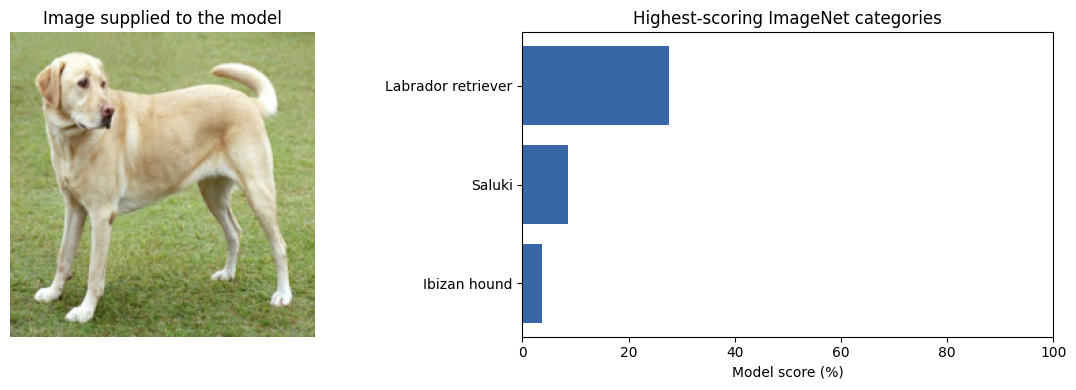

Sum over all categories: 1.0


In [ ]:
labels = [label.replace("_", " ") for _, label, _ in top_predictions]
scores = [float(score) * 100 for _, _, score in top_predictions]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(model_img)
axes[0].set_title("Image supplied to the model")
axes[0].axis("off")
axes[1].barh(labels, scores, color="#3767a6")
axes[1].invert_yaxis()
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Model score (%)")
axes[1].set_title("Highest-scoring ImageNet categories")
plt.tight_layout()
plt.show()

print("Sum over all categories:", float(predictions.sum()))

### Interpretation notes for the presenter

- Judge the label against the photo and the level of specificity expected by the application.
- A 90% softmax score expresses a model output for one image. Accuracy requires correct predictions counted over labelled test examples. A high score can accompany a wrong prediction.
- A whole-image classifier does not locate or count separate objects. Detection addresses object locations.
- The model always scores its existing categories. It has no explicit "unknown" category. It can assign a familiar label to an unfamiliar subject.
- For a new campus tagging task, first define the useful categories. Transfer learning with representative labelled data is one possible next step.

**Answers to the RGB checkpoint:** `[255, 0, 0]` is red, `[0, 0, 0]` is black, and `[255, 255, 255]` is white.

# Section 3: Investigating mistakes

> **Guiding question 4:** How does a change in the image affect the model's suggestion?

The following supplied code compares an original image, a moderately blurred image and a strongly blurred image. It always applies blur **after resizing**, so the blur radius has a comparable meaning.

Before running it, predict whether the highest-scoring label will change. After running it, compare the observed results with your prediction. Scores may increase or decrease. Keep the result as observed.

Changing an image for this experiment is a transformation at inference time. Data augmentation uses transformations to create additional training examples during training.

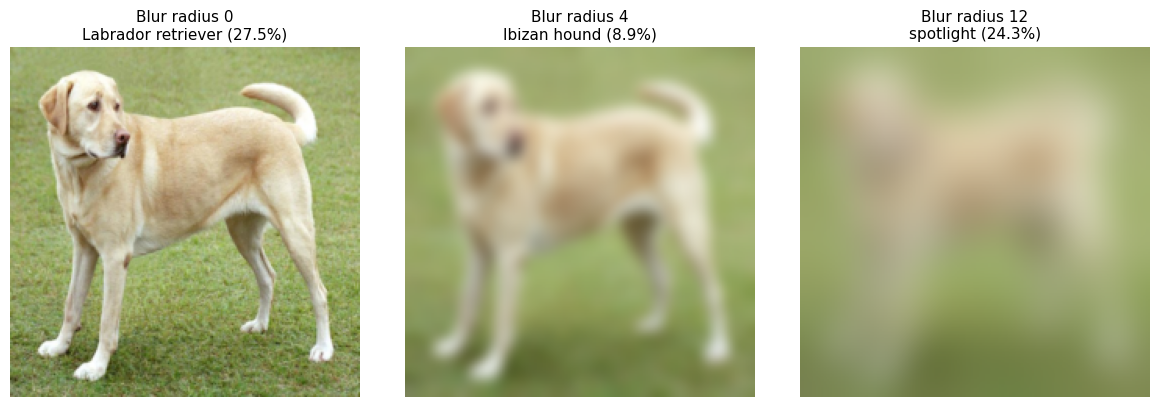

Radius  0: Labrador_retriever       27.5%
Radius  4: Ibizan_hound             8.9%
Radius 12: spotlight                24.3%


In [ ]:
blur_radii = [0, 4, 12]  # Try a different positive radius after the first comparison.
results = []
fig, axes = plt.subplots(1, len(blur_radii), figsize=(12, 4))

for axis, radius in zip(axes, blur_radii):
    changed_img = model_img.filter(ImageFilter.GaussianBlur(radius=radius))
    changed_batch = np.expand_dims(np.asarray(changed_img, dtype=np.float32), axis=0)
    changed_x = preprocess_input(changed_batch.copy())
    changed_predictions = model.predict(changed_x, verbose=0)
    _, label, score = decode_predictions(changed_predictions, top=1)[0][0]
    results.append({"blur_radius": radius, "label": label, "score": float(score)})
    axis.imshow(changed_img)
    axis.set_title(f"Blur radius {radius}\n{label.replace('_', ' ')} ({score:.1%})", fontsize=11)
    axis.axis("off")

plt.tight_layout()
plt.show()
for result in results:
    print(f"Radius {result['blur_radius']:>2}: {result['label']:<24} {result['score']:.1%}")

### Discussion notes for the presenter

Ask participants to report the labels and scores they actually observe. They can change in either direction. Blurring alters the input, while model parameters remain fixed.

Avoid turning this one-photo experiment into a claim about overall robustness. A stronger assessment would use many labelled photos representative of the intended setting, with planned transformations and a consistent evaluation method.

A useful answer to the open task states the question, shows the observed result, explains whether the label is useful, and identifies a limitation. There is no single expected prediction across uploaded photos.

# Section 4: Your turn

Choose **one question** below and investigate it with a new image. Change `image_source` to `"upload"`, rerun the image-loading cell, then rerun Sections 1 and 2. Keep the already-loaded model. Rerun Section 3 if your question involves blur.

- Does the model suggest a sensible label for a clear photo of an everyday object?
- How does it respond to a cluttered scene containing several objects?
- How does it respond to an SDS logo or another subject outside its existing categories?

### Your task

1. State your question and your expected outcome.
2. Run the code and record the actual highest-scoring label and score.
3. Describe whether the suggestion is useful for photo tagging.
4. State one limitation and one practical improvement you would investigate.

Do not treat a wrong prediction as a failed activity. It gives us something useful to explain. If your selected label seems sensible, that result alone still does not establish overall model accuracy.

| Item | Your answer |
| --- | --- |
| Question | ... |
| Expected outcome | ... |
| Image description | ... |
| Actual label and score | ... |
| Interpretation | ... |
| Limitation and proposed improvement | ... |

For a real application, define the intended categories, obtain labelled examples from the intended setting, and evaluate the system on separate examples. The gesture project later in this workshop develops that idea with landmark features.

# Section 5: Features and CNN intuition (optional presenter extension)

> **Guiding question 5:** What could useful visual features look like?

## A fixed edge filter

Traditional approaches can use a filter specified by a person to highlight changes in intensity. The supplied Pillow `FIND_EDGES` example illustrates one fixed operation. Edge responses can help describe an image, but an edge view by itself does not assign semantic labels.

The next cell is a conceptual illustration. Our MobileNetV2 classifier still receives the RGB image prepared in Section 2; it does not use this edge view as its input.

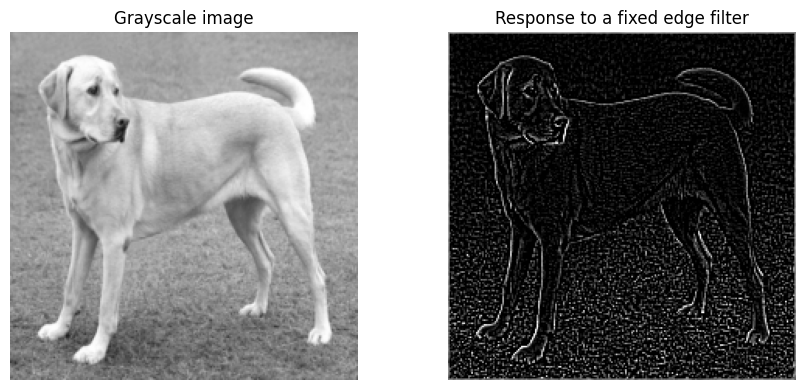

In [ ]:
gray_img = model_img.convert("L")
edge_img = gray_img.filter(ImageFilter.FIND_EDGES)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(gray_img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Grayscale image")
axes[1].imshow(edge_img, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Response to a fixed edge filter")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## Learned feature maps

A CNN learns filter parameters during training. The supplied cell extracts the output of MobileNetV2's first convolution layer and shows six of its feature maps for the current image.

Different channels can respond differently to the same photograph. These maps show internal responses. They are not object masks, attention maps, or a complete explanation of the final prediction. Do not assign a meaning such as "dog detector" to a channel just from looking at it.

Each map uses its own display range so its pattern is visible. Compare **where** responses occur, rather than interpreting relative brightness across panels as a common magnitude scale.

Layer: Conv1
Feature map shape (height, width, channels): (112, 112, 32)


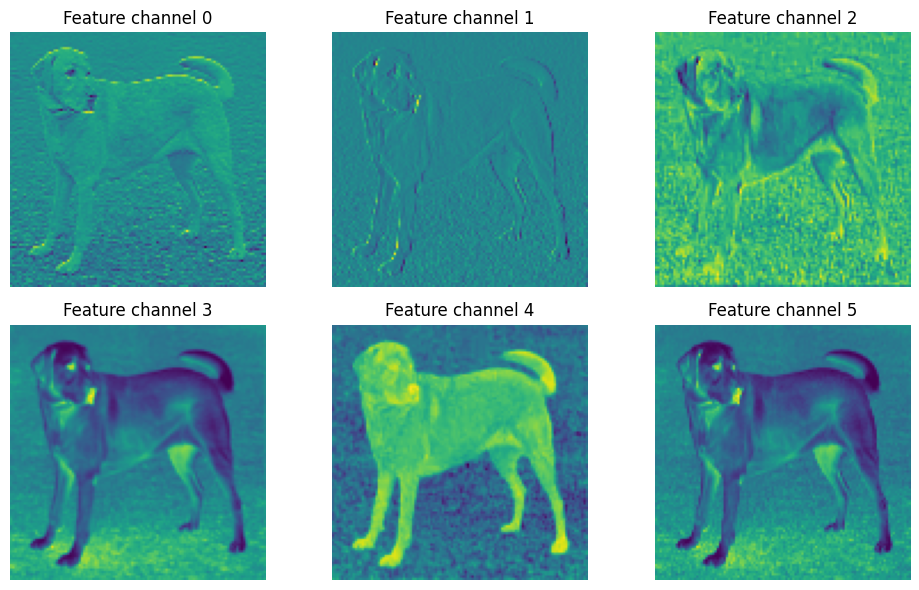

In [ ]:
first_conv = next(layer for layer in model.layers if isinstance(layer, tf.keras.layers.Conv2D))
feature_model = tf.keras.Model(inputs=model.inputs, outputs=first_conv.output)
feature_maps = feature_model.predict(x, verbose=0)[0]
print("Layer:", first_conv.name)
print("Feature map shape (height, width, channels):", feature_maps.shape)

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for channel, axis in enumerate(axes.flat):
    axis.imshow(feature_maps[:, :, channel], cmap="viridis")
    axis.set_title(f"Feature channel {channel}")
    axis.axis("off")
plt.tight_layout()
plt.show()

## Optional help with coding

The EDA workshop included practice in asking an LLM for coding help. You can use a short version of that approach here if it fits your segment.

**Example prompt:**

> I am using TensorFlow/Keras MobileNetV2 pretrained on ImageNet in Google Colab. My image array has shape (224, 224, 3) and float32 RGB values from 0 to 255. Explain how to create a batch of one image and apply the model's expected preprocessing. Give Python code and explain each line. Do not invent prediction results or change to another model.

Run the suggested code and compare its shapes, scaling and results with the notebook. Supply the exact error message when asking for help with an error. Only report model outputs you actually observe.

## Troubleshooting

| Symptom | Next step |
| --- | --- |
| Message says to complete an exercise | Replace that exercise's `None` with your code and rerun it |
| `NameError` | Run earlier cells in order, especially after restarting the runtime |
| Sample or weights cannot download | Check internet access, retry, or use presenter screenshots |
| Upload cell fails | Choose exactly one JPEG or PNG and rerun the image-loading cell |
| `google.colab` cannot import | Run the upload option in Colab |
| Unexpected batch shape | Check the RGB conversion, target size and batch dimension |
| Prediction seems wrong | Inspect the photo and preprocessing, and consider the model's fixed categories |

After changing an uploaded image, rerun its dependent cells. After changing only `top_k`, rerun the prediction and result-plot cells.

## References

- [Colab FAQ](https://research.google.com/colaboratory/faq.html): notebook upload and runtime behaviour.
- [TensorFlow MobileNetV2 API](https://www.tensorflow.org/api_docs/python/tf/keras/applications/MobileNetV2): model input, pretrained parameters and categories.
- [MobileNetV2 preprocessing](https://www.tensorflow.org/api_docs/python/tf/keras/applications/mobilenet_v2/preprocess_input): input scaling.
- [Keras Applications](https://keras.io/api/applications/): pretrained image classification workflow.
- [TensorFlow Keras Model API](https://www.tensorflow.org/api_docs/python/tf/keras/Model): extracting intermediate tensors.
- [TensorFlow transfer learning tutorial](https://www.tensorflow.org/tutorials/images/transfer_learning): adaptation to new categories.
- [Pillow image filters](https://pillow.readthedocs.io/en/stable/reference/ImageFilter.html): the supplied fixed edge-filter illustration.
- [TensorFlow sample-image tutorial](https://www.tensorflow.org/tutorials/generative/adversarial_fgsm): source of the Labrador example. This notebook does not implement the tutorial's adversarial attack.
- Sample image: [Wikimedia Commons file page](https://commons.wikimedia.org/wiki/File:YellowLabradorLooking_new.jpg), original Elf photo, derivative/retouch by Djmirko and FT2, [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/).

**Workshop references supplied by the organiser:** *Workshop Brainstrorm and Planning.pdf*, *(Participant Template) SDS_EDA_Workshop.ipynb*, *(Worked Solutions) SDS_EDA_Workshop.ipynb*, and *SDS Workshop EDA Slides.pdf*. The EDA materials informed the teaching structure; this notebook addresses the CV proposal's introductory classification segment.

# Presenter appendix: Wei Tao's introductory segment

## How the EDA references change the package

The supplied EDA participant notebook has **101 cells**, including **48 code cells** and **14 cells containing blanks**. Its worked solution has the same main sequence, fills the blanks, and includes saved outputs in 42 cells. The **106-page** EDA slide deck spans the whole EDA workshop and uses repeated pages to reveal information in stages.

The useful patterns to carry into this segment are a practical scenario, guiding questions, supplied setup, small coding exercises, interpretation after output, and a final open task. The CV pair uses five exercises so participants focus on the main input and prediction pipeline.

The slides first introduce concepts and examples, then transition to code. Their chart discussion also asks participants to inspect misleading results. The corresponding CV discussion concerns image changes, fixed categories and overinterpreting scores.

The EDA references illustrate the previous workshop's approach. They do not establish that a short introductory CV segment should have the same slide count or reproduce every topic.

## Suggested slide content

This is an **outline with copy and visual suggestions**, not a finished slide deck. It covers your proposal's introductory responsibilities. Detection, segmentation, IoU, NMS and MediaPipe implementation belong to the later presenters' sections.

### 1. Computer Vision

**On slide:** "Extracting useful information from images and video."

**Visual:** A few familiar examples, such as photo tags and a camera interpreting a scene.

**Presenter prompt:** Ask where participants have encountered an application that interprets images.

### 2. Image classification

**On slide:** "The model assigns a category to an image." Use a simple example: a photograph and the word "dog".

**Visual:** One photograph with a broad label beside it. Use an example without invented model scores.

**Presenter prompt:** Explain automatic photo tagging as the practical scenario for our prototype. Distinguish the broad teaching label from the fine-grained ImageNet labels the model will actually produce.

### 3. A photograph as data

**On slide:** "An image is an array of pixel values."

**Visual:** A photograph, a zoomed crop and a small numerical patch taken from the actual notebook image.

**Presenter prompt:** Ask whether a computer initially receives the word "dog" or an array of numbers.

### 4. RGB channels

**On slide:** "Each pixel stores red, green and blue values." Include `[255, 0, 0]` as a red example.

**Visual:** The three RGB intensity plots from Section 1, with the same 0-255 scale.

**Presenter prompt:** Ask participants to identify black and white from their RGB triples.

### 5. Image dimensions and batches

**On slide:** `(height, width, 3)` describes one RGB image. `(1, 224, 224, 3)` describes a batch containing one model input.

**Visual:** Label each dimension in these two shape tuples. Keep the labels large enough for projection.

**Presenter prompt:** Explain the leading `1` before opening the batching exercise.

### 6. Useful visual features

**On slide:** "Features capture information useful for a task." Mention edges, texture and shape as examples of visual patterns.

**Visual:** An original image and the fixed edge-filter view from Section 5.

**Presenter prompt:** Explain that a person can specify a traditional filter. This filter is a conceptual illustration, separate from the CNN's RGB input.

### 7. A convolutional filter

**On slide:** "A filter applies the same local operation at different image locations. Its responses form a feature map."

**Visual:** A small pixel patch, a small filter and the resulting response. If you show a numerical calculation, use an explicit toy example and label it as illustrative.

**Presenter prompt:** Use local pattern matching as intuition. Skip formal derivations unless the audience needs them.

### 8. Learned CNN representations

**On slide:** "Training learns filter parameters. Later layers combine earlier representations for the task."

**Visual:** Early feature maps from the optional notebook extension and a simple layer overview.

**Presenter prompt:** Explain simple-to-complex patterns as intuition. Individual channels need not have a neat human-readable meaning.

### 9. Training and inference

**On slide:** Training uses examples and a loss to update parameters. Inference uses the learned parameters to predict on new inputs.

**Visual:** A comparison showing where parameters change and where they stay fixed.

**Presenter prompt:** Ask which process we are performing in this notebook.

### 10. Pretrained models and transfer learning

**On slide:** A pretrained model has already learned from another dataset. Transfer learning adapts a learned representation for a new task.

**Visual:** An existing feature extractor with a new classifier for custom categories. Keep this explanation conceptual.

**Presenter prompt:** Uploading a new photo to this notebook performs inference. It does not add a new category or train the network.

### 11. The classification example

**On slide:** Our pipeline loads an image, resizes it, creates a batch, applies MobileNetV2 preprocessing, and predicts ImageNet labels.

**Visual:** A short numbered pipeline and a screenshot of the notebook's actual result after rehearsal.

**Presenter prompt:** Open the worked solution for a demo, or the participant template if the audience is completing the exercises.

### 12. Prediction scores

**On slide:** The model scores 1,000 categories. Its highest score can still accompany an incorrect prediction. Test accuracy counts correct predictions across labelled examples.

**Visual:** The notebook's bar chart from an actual run. Keep the 0-100% scale and label it "Model score (%)".

**Presenter prompt:** Ask what evidence we would need before deploying automatic photo tags.

### 13. Changing the image

**On slide:** "How does blur affect the suggestion?"

**Visual:** Actual original, moderate-blur and strong-blur outputs from Section 3.

**Presenter prompt:** Ask participants to predict the effect, run the code, then discuss the observed result without promising a particular direction.

### 14. Visual features for gesture recognition

**On slide:** "Visual information can become numerical features for different tasks." The next project uses hand landmarks and derived features to train a gesture classifier.

**Visual:** A hand photograph and an illustration of landmarks. The next presenter supplies the actual landmark demonstration.

**Presenter prompt:** Hand over to Brytania's explanation of CV tasks and hand landmarks.

## Suggested sequence and timing

These are planning options for your own segment, subject to the organisers' final allocation.

| Block | Compact presenter demo | With participant coding |
| --- | --- | --- |
| Concepts, slides 1-10 | About 10-12 minutes | About 10-12 minutes |
| Notebook, Sections 0-2 | About 10-15 minutes | About 20-25 minutes |
| Scores, optional blur, handover | About 3-5 minutes | About 3-5 minutes |
| Total for your segment | About 23-32 minutes | About 33-42 minutes |

For a shorter allocation, merge the RGB and dimensions slides, keep convolution to one intuitive explanation, and run only the core notebook. Sections 3-5 can become extra material after the workshop. The two-hour event also needs time for the later presenters and gesture project.

## Preparation checklist

1. Run the worked solution from the top in a fresh standard Colab runtime. Use the sample image first.
2. Rehearse three selected photos: a clear subject, a cluttered scene and a subject outside the classifier's categories.
3. Save the solution with actual outputs and capture the key plots for slides and connectivity backup. Keep the image credit with the sample-photo views.
4. Share the participant notebook and check that a participant can open it, download the sample and reach Exercise 1 without a custom local path.
5. If you demonstrate the fixed edge filter or feature maps, rehearse those optional cells too.
6. Coordinate segment timings and the landmark handover with Brytania and Ang Xuan.
7. Add feedback and SDS resource links once the organisers provide the current destinations. The EDA deck includes these at the end of its full workshop; reuse the idea with the current workshop's links.

## Common questions and answers

**Why resize?** Our chosen classifier expects a particular input resolution. Other architectures and configurations may differ.

**Why add a batch dimension?** The model input format accommodates several images at once, even when we provide only one.

**Why can it guess a category outside the true subject?** It always scores the existing ImageNet categories and has no explicit unknown category.

**Why use pretrained weights?** They provide a learned representation so we can demonstrate inference without first collecting a dataset and training the CNN.

**Why not call `fit()`?** `fit()` trains parameters. The later gesture exercise covers training another classifier from labelled feature examples.

**Can it tell us where the dog is?** Whole-image classification gives category scores. Detection introduces object locations, which the next presenter will explain.

**Does the feature-map view explain the prediction?** It shows some intermediate responses. It does not prove which information caused the final label.

## Execution status

This version supplies complete solutions and explanation notes. Notebook structure, Python syntax and the Pillow/NumPy input preparation were checked during preparation. TensorFlow inference, downloads, Colab uploads and the optional learned-feature cells have not been executed here because TensorFlow is unavailable locally. No saved prediction outputs or invented result percentages are included. A full Colab rehearsal remains necessary before sharing the material as workshop-ready.